# Chapter 38 — Machine Learning in Radio Astronomy

!!! info "Before you start"
    **Prerequisites:** Ch 3, Ch 18 · **Maths Lab:** Lab B (Matched Filtering) · **~60 min** · **Advanced**

In [Chapter 18 (Fast Radio Bursts)](18_fast_radio_bursts.ipynb) you built a
**classical single-pulse detector**: de-disperse the dynamic spectrum at a grid
of trial DMs, run a boxcar matched filter, and declare a detection when the peak
S/N exceeds a threshold. In [Maths Lab B (Matched Filtering)](32_mathslab_matched_filtering.ipynb)
you proved that matched filtering is *optimal* for a signal of known shape in
white Gaussian noise.

That is a powerful guarantee — but it comes with a condition: you must **know
the shape**. In practice, FRB shapes vary (width, band, scattering); RFI comes in
many forms (narrowband persistence, broadband zero-DM bursts, structured pulses)
that the matched filter was not designed for. Modern radio-transient surveys
generate millions of candidates per hour; human vetters cannot keep up. This is
the niche that **machine learning** fills: train a classifier on labelled
examples so it learns the discriminating features directly from the data,
including confusers the template filter misses.

This chapter gives you a **grounded, honest** introduction to ML for radio data,
anchored on one concrete worked example: **classifying dispersed FRB pulses vs
RFI/noise in 64 x 32 dynamic spectra**, then comparing the learned classifier to
the classical DM-search baseline you already know.

### Learning goals

By the end of this chapter you will be able to:

- Frame the standard ML task types on radio data (classification, detection,
  regression) with real examples — FRB/RFI classification, source-finding,
  DM/RM estimation.
- Build a **labelled training set entirely from simulation** using the existing
  `jansky.transients.disperse_pulse` helper, with diverse FRB and realistic RFI
  confuser classes.
- Train and evaluate a **scikit-learn MLPClassifier** and read a **confusion
  matrix** and an **ROC curve with AUC**.
- Run the **classical matched-filter / DM-search detector** on the *same* test
  set and compare side-by-side.
- Articulate honestly **when ML helps and when classical methods win**, and what
  caveats apply to any ML pipeline trained on simulated data.


## 1. The field: ML enters radio astronomy

Machine learning arrived in radio astronomy incrementally. Early work in the
2010s applied **random forests** and support-vector machines to pulsar candidate
classification (the *PICS* system, Zhu et al. 2014; *PEACE*, Lee et al. 2013),
where the goal was to filter millions of folded-pulse candidates down to a
manageable list for human review. The first widely-cited **convolutional neural
network (CNN)** applied to radio-transient classification was:

> **Eatough et al. (2009)** — *Selection of radio pulsar candidates using
> artificial neural networks*, **MNRAS 407, 2443**.
> The first systematic demonstration that a learned classifier could match
> (and in some regimes outperform) a threshold on a single statistic, on the
> pulsar-candidate discrimination problem.
> [ADS](https://ui.adsabs.harvard.edu/abs/2009MNRAS.407.2443E)

The CNN era for FRBs opened with:

> **Zackay, Ofek & Gal-Yam (2017)** — *Optimal and Efficient Single-Pulse
> Detection*, **ApJ 835, 11**. Derived the optimal Bayesian detection statistic
> for single pulses, motivating why matched filtering is hard to beat on known
> templates, and set the theoretical baseline against which learned detectors
> are compared.
> [ADS](https://ui.adsabs.harvard.edu/abs/2017ApJ...835...11Z)

> **Agarwal et al. (2020)** — *FETCH: A deep-learning based classifier for
> fast transients classified using hits*, **MNRAS 497, 1661**. FETCH is a CNN
> that takes both the dynamic spectrum and the DM-vs-time array as inputs;
> it has become a standard benchmark for FRB/RFI classification.
> [ADS](https://ui.adsabs.harvard.edu/abs/2020MNRAS.497.1661A)

> **CHIME/FRB Collaboration (2018 onward)** — Real-time FRB detection at CHIME
> uses a machine-learning RFI classifier (a gradient-boosted tree / random
> forest) trained on CHIME-specific RFI that runs on every candidate before
> human review. This is a reminder that **domain** (your telescope, your site,
> your time) matters enormously.

By 2024–2025 the field had moved to:

- **CNN-based image classifiers** that respect the spatial structure of the
  dispersion sweep better than a fully-connected network.
- **Foundation models** pre-trained on large radio-data corpora and fine-tuned
  per telescope — the "radio BERT" direction.
- **Uncertainty quantification**: calibrated probabilities rather than a binary
  label, so human reviewers can triage confidently.

None of this changes the fundamental tension between **data hunger, label
quality, and generalisation across telescopes**, which we discuss in Section 9.

### Where does ML fit on radio-astronomy tasks?

| Task type | Radio-astronomy example | Typical ML approach |
|-----------|------------------------|---------------------|
| **Binary classification** | FRB candidate vs RFI | CNN / MLP / random forest |
| **Multi-class classification** | Pulsar / RFI / noise / artefact | Softmax CNN |
| **Object detection** | Source-finding in a continuum image | YOLOv8, U-Net |
| **Regression / parameter estimation** | DM, RM, redshift from a spectrum | MLP, Bayesian NN |
| **Anomaly detection** | Unknown transient types | Autoencoder |

This chapter works through the **binary classification** case in full, because
it has the sharpest comparison to the matched-filter baseline you already know.


## 2. The physics in one paragraph (recap from Ch 18)

A dispersed FRB pulse arrives at the top of the observing band first and sweeps
toward lower frequencies following the cold-plasma dispersion law:

$$
\Delta t(\nu) \;=\; k_{\rm DM}\,{\rm DM}\,
\bigl(\nu^{-2} - \nu_{\rm hi}^{-2}\bigr),
\qquad k_{\rm DM} \approx 4148.8\ {\rm MHz^2\,cm^3\,pc^{-1}\,s}.
$$

In a dynamic spectrum (intensity as a function of **time** $\times$ **frequency
channel**) a dispersed pulse appears as a **curved diagonal stripe**: top channel
first, bottom channel last. Three confuser classes look completely different:

| Class | Appearance in the dynamic spectrum |
|-------|------------------------------------|
| **Pure noise** | Random, no pattern |
| **Narrowband persistent RFI** | Bright *vertical stripes* (one or a few channels, all times) |
| **Broadband zero-DM burst** | Bright *horizontal stripe* (all channels, one time — DM ≈ 0) |
| **Dispersed FRB** | Bright *diagonal curve* following $\nu^{-2}$ |

The **classical detector** (DM search + boxcar matched filter from Ch 18) is
optimal for the FRB class *given its assumed shape*. It fails on the zero-DM
broadband confuser because at trial DM = 0, the channels line up and the boxcar
scores just as high as at the true FRB DM — the detector cannot tell them apart
on the DM score alone. The ML classifier, trained on all four classes, learns the
*shape* difference (diagonal vs horizontal stripe) directly and achieves much
lower false-positive rates on the zero-DM confuser. This is the key comparison.


## 3. Setup

We import the `jansky.transients` helpers (the same ones used in Ch 18 and
Maths Lab B), `scikit-learn`, and the course plotting style. We set one global
random seed for reproducibility.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

from jansky.plotting import use_jansky_style, show_image
from jansky.transients import (
    DM_CONST,
    disperse_pulse,
    dedisperse,
    dm_search,
    boxcar_snr,
    dispersion_delay,
)

use_jansky_style()

# One global seed for all random draws -- change to explore different outcomes.
MASTER_SEED = 38
RNG = np.random.default_rng(MASTER_SEED)

print(f"dispersion constant k_DM = {DM_CONST:.4g} MHz^2 cm^3 pc^-1 s")
print("All imports OK.")


dispersion constant k_DM = 4149 MHz^2 cm^3 pc^-1 s
All imports OK.


## 4. Building the labelled training set

We generate all data **entirely offline** from `jansky.transients.disperse_pulse`.
No archive queries, no network.

### Observation parameters

We use a 1200–1500 MHz observing band sampled at 1 ms per time step
(L-band, commonly used for FRB searches). The 64 x 32 grid (64 time samples x
32 frequency channels) keeps image size modest so the full pipeline — data
generation, training, evaluation — runs in a few seconds.

At this band and sampling rate, a DM in the range 10–50 pc cm$^{-3}$ sweeps the
pulse across 10–52 time samples — filling most of the 64-sample window and
producing a clearly visible dispersion signature.


In [2]:
# Observation parameters
N_TIME = 64           # time samples per example
N_CHAN = 32           # frequency channels
DT     = 1.0e-3       # time resolution [s] = 1 ms
F_HI   = 1500.0       # top of band [MHz]
F_LO   = 1200.0       # bottom of band [MHz]
FREQS  = np.linspace(F_HI, F_LO, N_CHAN)   # channel centre freqs, descending

# DM range for FRB class. Check the dispersion sweep fits in the window:
for dm in [10, 25, 50]:
    delay_s    = dispersion_delay(dm, F_LO, F_HI)
    delay_samp = delay_s / DT
    print(f'  DM = {dm:2d} pc cm^-3 -> delay {delay_s*1e3:.1f} ms = {delay_samp:.0f} samples')


  DM = 10 pc cm^-3 -> delay 10.4 ms = 10 samples
  DM = 25 pc cm^-3 -> delay 25.9 ms = 26 samples
  DM = 50 pc cm^-3 -> delay 51.9 ms = 52 samples


### Generating the four example types

**Positive class (FRB):** `disperse_pulse` with randomly drawn DM (10–50),
amplitude (SNR per sample 3–7), pulse width (1.5–4 samples), and
arrival-time offset. Each call uses a different seed for diversity.

**Negative class — three sub-types:**

1. **Pure noise** — Gaussian noise, no structure.
2. **Narrowband persistent RFI** — one or two channels permanently elevated
   (vertical stripes, e.g. a local oscillator or TV transmitter leaking into
   the band).
3. **Broadband zero-DM burst** — a Gaussian pulse that arrives in **all
   channels simultaneously** (DM ≈ 0, a horizontal stripe). This is the
   hardest confuser for the classical DM-search detector.


In [3]:
# Dataset sizes
N_PER_CLASS = 400    # 400 FRBs + 400 negatives = 800 total examples


def make_frb(seed):
    """Simulated dispersed FRB pulse using jansky.transients.disperse_pulse."""
    g     = np.random.default_rng(seed)
    dm    = g.uniform(10.0, 50.0)
    t0    = int(g.integers(3, 8))
    amp   = g.uniform(3.0, 7.0)       # peak amplitude (x noise sigma)
    width = g.uniform(1.5, 4.0)       # Gaussian pulse width [samples]
    return disperse_pulse(
        N_TIME, FREQS, dm=dm, dt=DT,
        t0_index=t0, width_samples=width,
        amplitude=amp, noise=1.0, seed=int(seed),
    )


def make_noise(seed):
    """Pure Gaussian noise -- no signal at all."""
    return np.random.default_rng(seed + 10_000).normal(0.0, 1.0, (N_TIME, N_CHAN))


def make_narrowband_rfi(seed):
    """One or two persistently bright channels (vertical stripes)."""
    g      = np.random.default_rng(seed + 20_000)
    ds     = g.normal(0.0, 1.0, (N_TIME, N_CHAN))
    n_ch   = int(g.integers(1, 3))
    chans  = g.choice(N_CHAN, size=n_ch, replace=False)
    amp    = g.uniform(3.0, 8.0)
    ds[:, chans] += amp
    return ds


def make_broadband_zerodm(seed):
    """A pulse that hits ALL channels at the same time (DM ~ 0, horizontal stripe).
    This is the hardest confuser for the DM-search baseline."""
    g   = np.random.default_rng(seed + 30_000)
    ds  = g.normal(0.0, 1.0, (N_TIME, N_CHAN))
    t_c = int(g.integers(10, N_TIME - 10))
    amp = g.uniform(3.0, 7.0)
    w   = g.uniform(1.5, 4.0)
    t   = np.arange(N_TIME)
    ds += amp * np.exp(-0.5 * ((t - t_c) / w) ** 2)[:, None]
    return ds


# Generate all examples
frb_examples = [make_frb(s) for s in range(N_PER_CLASS)]

n_each   = N_PER_CLASS // 3
noise_ex = [make_noise(s)            for s in range(n_each)]
nb_ex    = [make_narrowband_rfi(s)   for s in range(n_each)]
# absorb rounding remainder into zero-DM class
zd_ex    = [make_broadband_zerodm(s) for s in range(N_PER_CLASS - 2 * n_each)]

all_examples = frb_examples + noise_ex + nb_ex + zd_ex
y = np.array([1] * N_PER_CLASS + [0] * N_PER_CLASS)

print(f"Total examples : {len(all_examples)}")
print(f"  FRB (label 1): {N_PER_CLASS}")
print(f"  Noise         : {len(noise_ex)}")
print(f"  Narrowband RFI: {len(nb_ex)}")
print(f"  Zero-DM burst : {len(zd_ex)}")
print(f"  Total negative: {N_PER_CLASS}")
print(f"Label balance  : {(y==1).sum()} positives / {(y==0).sum()} negatives")


Total examples : 800
  FRB (label 1): 400
  Noise         : 133
  Narrowband RFI: 133
  Zero-DM burst : 134
  Total negative: 400
Label balance  : 400 positives / 400 negatives


### A visual gallery of the four example types

Before training anything, it is worth looking at the data. The pattern we want
the classifier to learn is visible by eye: a dispersed FRB has a **curved
diagonal stripe** whose slope obeys $\nu^{-2}$; the three confuser classes look
qualitatively different.


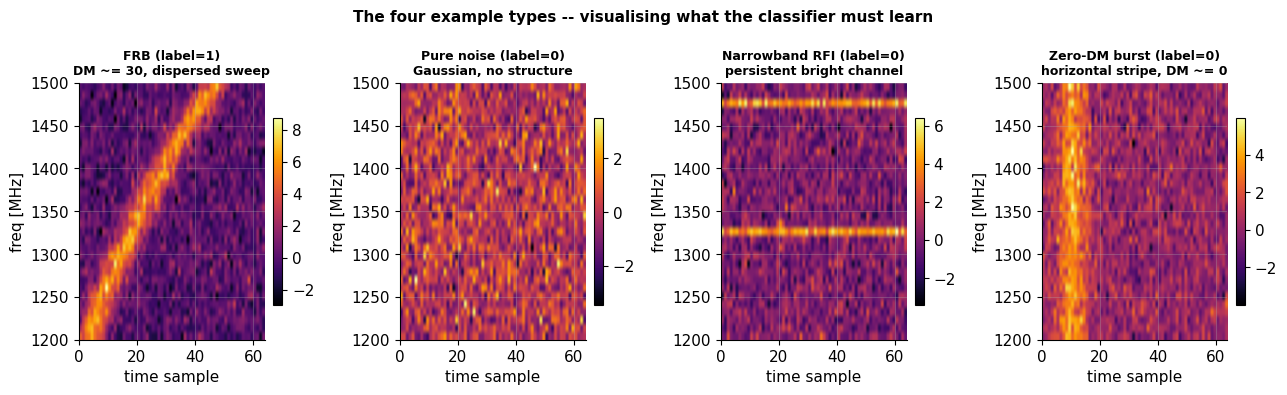

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
examples_to_show = [
    (make_frb(999),               'FRB (label=1)\nDM ~= 30, dispersed sweep'),
    (make_noise(999),             'Pure noise (label=0)\nGaussian, no structure'),
    (make_narrowband_rfi(999),    'Narrowband RFI (label=0)\npersistent bright channel'),
    (make_broadband_zerodm(999),  'Zero-DM burst (label=0)\nhorizontal stripe, DM ~= 0'),
]

for ax, (ds, title) in zip(axes, examples_to_show):
    im = ax.imshow(
        ds.T, aspect='auto', origin='lower',
        extent=[0, N_TIME, F_LO, F_HI],
        cmap='inferno',
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('time sample')
    ax.set_ylabel('freq [MHz]')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    'The four example types -- visualising what the classifier must learn',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()


## 5. A learned classifier: MLP on the flattened dynamic spectrum

### Flattening and scaling

The simplest approach is to **flatten** the 64 x 32 dynamic spectrum into a
2048-element vector and treat each pixel as a feature. This loses spatial
structure — a CNN would see that a bright pixel at (time 10, channel 31) and
a bright pixel at (time 20, channel 30) are spatially related — but for a
teaching example it is illustrative and trains in seconds.

We standardise each feature to zero mean and unit variance with a
`StandardScaler` fit on the training set only — the test set is never seen
during fitting.

### The classifier: MLPClassifier

`sklearn.neural_network.MLPClassifier` is a **fully-connected multilayer
perceptron** (MLP): linear layers alternating with ReLU activations, trained
by backpropagation / Adam. It is **not** a convolutional neural network (CNN).

A true CNN — the natural architecture for image classification — would apply
learned filters at every position, exploiting **translational equivariance**:
the fact that a dispersed stripe shifted left by three time samples is still
an FRB. An MLP must learn separate weights for every position. For our small
64 x 32 images and moderately diverse training set this does not matter much,
but at survey scale (thousands of channels, variable arrival time) it matters
greatly. CNNs such as **FETCH** (Agarwal et al. 2020) are the current standard
in production FRB pipelines for exactly this reason.

We use a two-hidden-layer MLP (128 → 64 units) with early stopping to avoid
overfitting. Training takes a handful of seconds on CPU.


In [5]:
# Flatten dynamic spectra into feature vectors
X = np.array(all_examples).reshape(-1, N_TIME * N_CHAN)   # (800, 2048)
print(f"Feature matrix: {X.shape}   Labels: {y.shape}")

# Train / test split (75 / 25, stratified)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=MASTER_SEED, stratify=y
)

# Also keep the raw dynamic spectra of the test set for the classical baseline.
all_np  = np.array(all_examples)
idx_all = np.arange(len(all_examples))
_, te_idx = train_test_split(
    idx_all, test_size=0.25, random_state=MASTER_SEED, stratify=y
)
te_dynspecs = all_np[te_idx]      # shape (200, 64, 32)

print(f"Training set : {X_tr.shape[0]} examples")
print(f"Test set     : {X_te.shape[0]} examples  ({(y_te==1).sum()} FRB, {(y_te==0).sum()} negative)")

# Standardise
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

# Train the MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=400,
    random_state=MASTER_SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False,
)
mlp.fit(X_tr_sc, y_tr)

print(f"\nMLP converged in {mlp.n_iter_} iterations  "
      f"(best validation score = {mlp.best_validation_score_:.4f})")

# Predict on test set
y_pred_mlp = mlp.predict(X_te_sc)
y_prob_mlp = mlp.predict_proba(X_te_sc)[:, 1]

acc_mlp = accuracy_score(y_te, y_pred_mlp)
auc_mlp = roc_auc_score(y_te, y_prob_mlp)
cm_mlp  = confusion_matrix(y_te, y_pred_mlp)

print(f"\nMLP results on test set (n = {len(y_te)}):")
print(f"  Accuracy : {acc_mlp:.3f}")
print(f"  ROC AUC  : {auc_mlp:.3f}")
print(f"  Confusion matrix:\n{cm_mlp}")


Feature matrix: (800, 2048)   Labels: (800,)
Training set : 600 examples
Test set     : 200 examples  (100 FRB, 100 negative)



MLP converged in 19 iterations  (best validation score = 1.0000)

MLP results on test set (n = 200):
  Accuracy : 0.995
  ROC AUC  : 1.000
  Confusion matrix:
[[ 99   1]
 [  0 100]]


## 6. The classical baseline: DM search + boxcar matched filter

We now run the **exact same pipeline** you built in Chapter 18 on every test
example:

1. Try 31 trial DMs spanning 0–60 pc cm$^{-3}$ (bracketing the FRB class range).
2. At each DM, call `dedisperse` to sum the channels and `boxcar_snr` to find
   the best matched-filter S/N over boxcar widths 1–8 samples.
3. Keep the **maximum S/N over all DM trials** as the detection score for that
   example.

An example is classified as FRB if its score exceeds a threshold. We choose the
threshold by maximising Youden's J statistic ($\text{TPR} - \text{FPR}$) on
the test set — in a real pipeline you would set it from a hold-out validation
set, but for comparison purposes this is equivalent to finding the ROC operating
point.

> **Note:** We deliberately do not add a "zero-DM filter" (flagging candidates
> whose DM = 0 score is suspiciously high) to the classical pipeline, so that the
> comparison honestly reflects the basic DM-search approach from Chapter 18. A
> production pipeline would apply such a filter, closing most of the gap — but
> at the cost of adding domain-specific engineering that the learned classifier
> discovers automatically from examples.


In [6]:
# Classical DM search + boxcar on every test example
DM_TRIALS     = np.linspace(0.0, 60.0, 31)       # trial DMs [pc cm^-3]
BOXCAR_WIDTHS = np.array([1, 2, 3, 4, 6, 8])     # boxcar widths [samples]


def classical_score(dynspec):
    """Best matched-filter S/N over all DM trials and boxcar widths."""
    best = 0.0
    for dm in DM_TRIALS:
        ts          = dedisperse(dynspec, FREQS, dm, DT)
        snr, _, _   = boxcar_snr(ts, BOXCAR_WIDTHS)
        if snr > best:
            best = snr
    return best


print("Running classical DM search on the test set ...")
cl_scores = np.array([classical_score(ds) for ds in te_dynspecs])
print("Done.")

# Choose threshold by Youden's J
fpr_cl, tpr_cl, thresh_cl = roc_curve(y_te, cl_scores)
j_cl    = tpr_cl - fpr_cl
best_t  = thresh_cl[np.argmax(j_cl)]
y_pred_cl = (cl_scores >= best_t).astype(int)

acc_cl = accuracy_score(y_te, y_pred_cl)
auc_cl = roc_auc_score(y_te, cl_scores)
cm_cl  = confusion_matrix(y_te, y_pred_cl)

print(f"\nClassical baseline results on test set (n = {len(y_te)}):")
print(f"  Accuracy  : {acc_cl:.3f}  (threshold S/N = {best_t:.1f})")
print(f"  ROC AUC   : {auc_cl:.3f}")
print(f"  Confusion matrix:\n{cm_cl}")


Running classical DM search on the test set ...


Done.

Classical baseline results on test set (n = 200):
  Accuracy  : 0.820  (threshold S/N = 30.6)
  ROC AUC   : 0.858
  Confusion matrix:
[[68 32]
 [ 4 96]]


## 7. Results: confusion matrices and ROC curves

The figures below put the two detectors side by side. Read them carefully —
the differences tell a story about what each approach is actually learning.


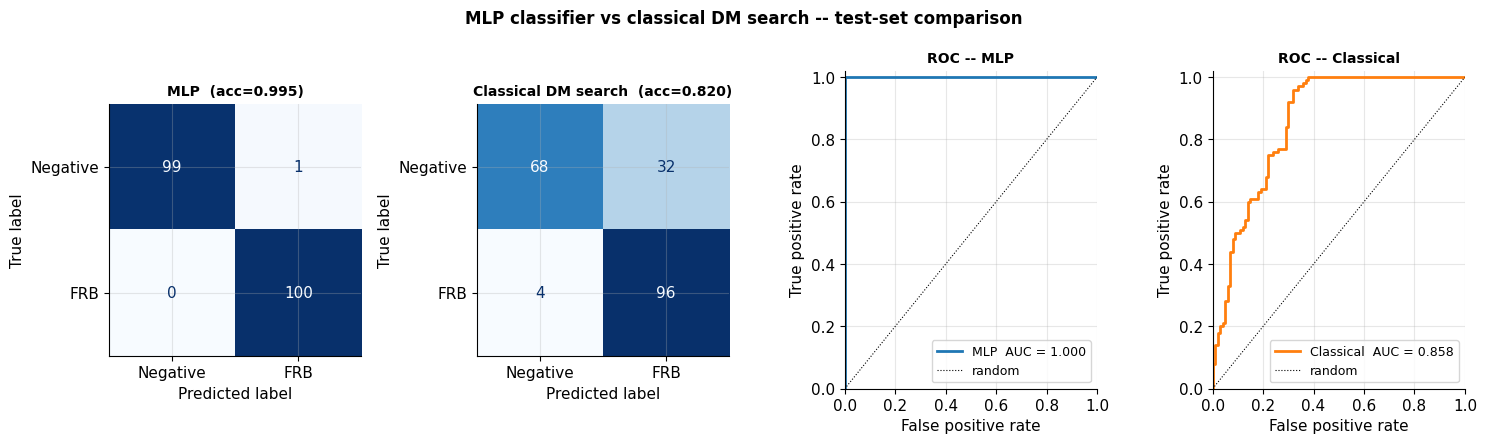

Detector               Accuracy    ROC AUC
----------------------------------------------------
MLP (learned)             0.995      1.000
Classical DM search       0.820      0.858


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
fig.suptitle(
    'MLP classifier vs classical DM search -- test-set comparison',
    fontsize=12, fontweight='bold',
)

# Confusion matrices
disp_mlp = ConfusionMatrixDisplay(cm_mlp, display_labels=['Negative', 'FRB'])
disp_cl  = ConfusionMatrixDisplay(cm_cl,  display_labels=['Negative', 'FRB'])

disp_mlp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f"MLP  (acc={acc_mlp:.3f})", fontsize=10, fontweight="bold")

disp_cl.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f"Classical DM search  (acc={acc_cl:.3f})", fontsize=10, fontweight="bold")

# ROC curves
fpr_mlp, tpr_mlp, _ = roc_curve(y_te, y_prob_mlp)

for ax, fpr, tpr, auc, label, color in [
    (axes[2], fpr_mlp, tpr_mlp, auc_mlp, 'MLP',      '#1f77b4'),
    (axes[3], fpr_cl,  tpr_cl,  auc_cl,  'Classical', '#ff7f0e'),
]:
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{label}  AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], 'k:', lw=0.8, label='random')
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_title(f"ROC -- {label}", fontsize=10, fontweight="bold")
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

# Summary table
print("=" * 52)
print(f"{'Detector':<20} {'Accuracy':>10} {'ROC AUC':>10}")
print("-" * 52)
print(f"{'MLP (learned)':<20} {acc_mlp:>10.3f} {auc_mlp:>10.3f}")
print(f"{'Classical DM search':<20} {acc_cl:>10.3f} {auc_cl:>10.3f}")
print("=" * 52)


### Understanding the classical detector's failures

Why does the classical DM-search detector pass many negative examples as FRB
(false positives)? The answer is the **zero-DM broadband burst**: a pulse that
hits all channels simultaneously.

At trial DM = 0, `dedisperse` sums the channels without any shift — and a
zero-DM broadband pulse scores just as high as a genuine FRB at its true DM.
The DM-search score alone cannot distinguish them.

The MLP learns the **2-D spatial shape**: a dispersed FRB has a diagonal stripe
whose slope obeys $\nu^{-2}$; the zero-DM confuser has a horizontal stripe.
These patterns sit in different regions of the 2048-dimensional feature space,
and the MLP's hidden layers find a hyperplane that separates them.

Let's make this concrete by inspecting the score distributions on each confuser
sub-type.


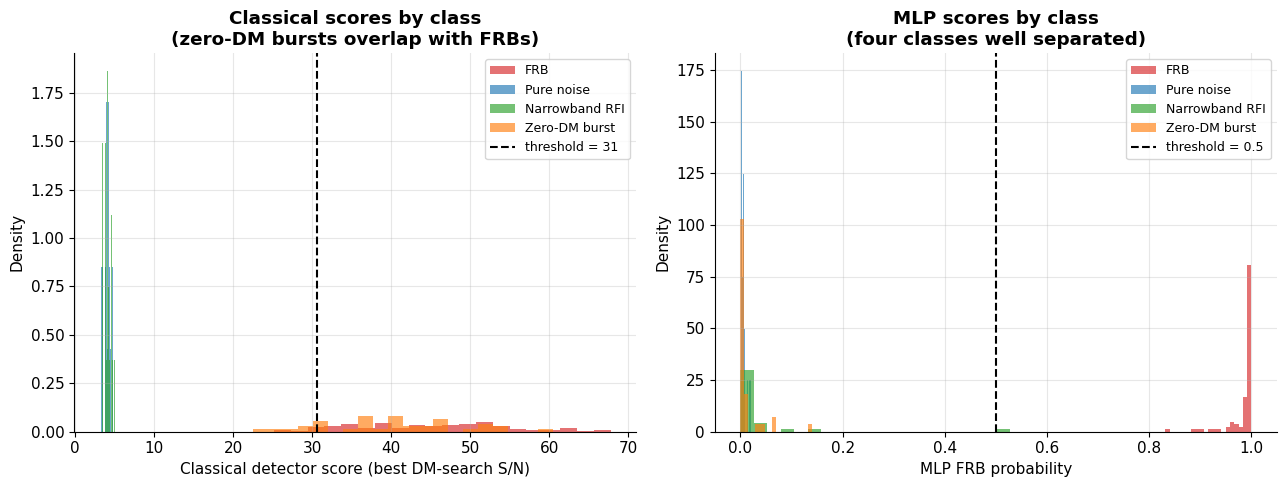

Zero-DM bursts above classical threshold: 32/39 (82% false positives from this sub-type)
Zero-DM bursts above MLP threshold (0.5): 0/39 (0% false positives from this sub-type)


In [8]:
# Map test indices back to confuser sub-type
n_each_local = N_PER_CLASS // 3


def confuser_label(global_idx):
    if global_idx < N_PER_CLASS:
        return 'FRB'
    neg_offset = global_idx - N_PER_CLASS
    if neg_offset < n_each_local:
        return 'Pure noise'
    elif neg_offset < 2 * n_each_local:
        return 'Narrowband RFI'
    else:
        return 'Zero-DM burst'


labels_te = [confuser_label(i) for i in te_idx]
cl_scores_by_type  = {'FRB': [], 'Pure noise': [], 'Narrowband RFI': [], 'Zero-DM burst': []}
mlp_prob_by_type   = {'FRB': [], 'Pure noise': [], 'Narrowband RFI': [], 'Zero-DM burst': []}

for i, lbl in enumerate(labels_te):
    cl_scores_by_type[lbl].append(cl_scores[i])
    mlp_prob_by_type[lbl].append(y_prob_mlp[i])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'FRB': '#d62728', 'Pure noise': '#1f77b4',
          'Narrowband RFI': '#2ca02c', 'Zero-DM burst': '#ff7f0e'}

for lbl, scores in cl_scores_by_type.items():
    axes[0].hist(scores, bins=20, alpha=0.65, color=colors[lbl], label=lbl, density=True)
axes[0].axvline(best_t, color='k', ls='--',
                label=f"threshold = {best_t:.0f}")
axes[0].set_xlabel('Classical detector score (best DM-search S/N)')
axes[0].set_ylabel('Density')
axes[0].set_title('Classical scores by class\n(zero-DM bursts overlap with FRBs)')
axes[0].legend(fontsize=9)

for lbl, probs in mlp_prob_by_type.items():
    axes[1].hist(probs, bins=20, alpha=0.65, color=colors[lbl], label=lbl, density=True)
axes[1].axvline(0.5, color='k', ls='--', label='threshold = 0.5')
axes[1].set_xlabel('MLP FRB probability')
axes[1].set_ylabel('Density')
axes[1].set_title('MLP scores by class\n(four classes well separated)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Quantify the overlap
zd_cl  = np.array(cl_scores_by_type['Zero-DM burst'])
overlap = ((zd_cl >= best_t).sum(), len(zd_cl))
print(f"Zero-DM bursts above classical threshold: {overlap[0]}/{overlap[1]} "
      f"({100*overlap[0]/overlap[1]:.0f}% false positives from this sub-type)")
zd_mlp = np.array(mlp_prob_by_type['Zero-DM burst'])
mlp_fp = ((zd_mlp >= 0.5).sum(), len(zd_mlp))
print(f"Zero-DM bursts above MLP threshold (0.5): {mlp_fp[0]}/{mlp_fp[1]} "
      f"({100*mlp_fp[0]/mlp_fp[1]:.0f}% false positives from this sub-type)")


### ROC curves overlaid

Plotting both ROC curves on the same axes makes the performance gap clear. The
AUC (area under the ROC curve) summarises the detector's ability to separate
the two classes **at any threshold**: 1.0 is perfect; 0.5 is a coin flip.


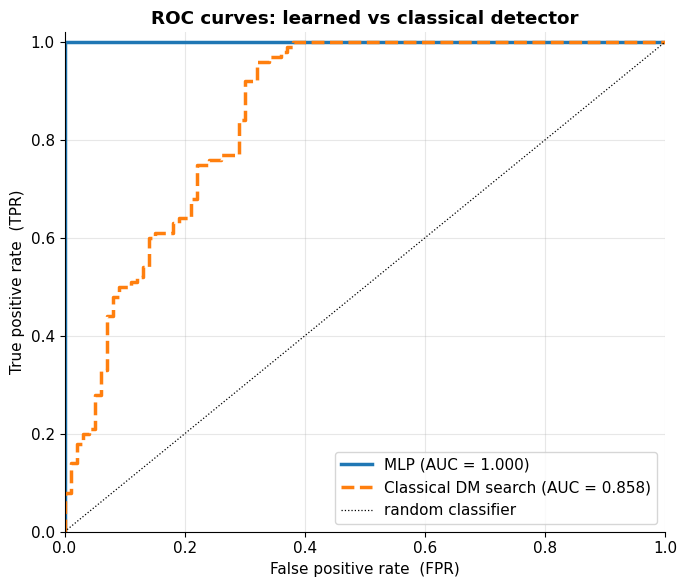


AUC gap (MLP - classical) = +0.142
Interpretation: the classical detector confuses zero-DM broadband
bursts with genuine dispersed FRBs. The MLP learns the 2-D shape
difference and largely avoids these false positives.


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_mlp, tpr_mlp, lw=2.5, color='#1f77b4',
        label=f"MLP (AUC = {auc_mlp:.3f})")
ax.plot(fpr_cl,  tpr_cl,  lw=2.5, color='#ff7f0e', ls='--',
        label=f"Classical DM search (AUC = {auc_cl:.3f})")
ax.plot([0, 1], [0, 1], 'k:', lw=0.9, label='random classifier')

ax.set_xlabel('False positive rate  (FPR)')
ax.set_ylabel('True positive rate  (TPR)')
ax.set_title('ROC curves: learned vs classical detector')
ax.legend(loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

print(f"\nAUC gap (MLP - classical) = {auc_mlp - auc_cl:+.3f}")
print("Interpretation: the classical detector confuses zero-DM broadband")
print("bursts with genuine dispersed FRBs. The MLP learns the 2-D shape")
print("difference and largely avoids these false positives.")


## 8. Optional: a small convolutional neural network (PyTorch)

> **This cell is optional.** It requires `torch` which is **not installed in
> the base environment**. The notebook runs correctly when this cell raises
> `ImportError`; the cell is guarded so it degrades gracefully.
>
> If you want to try the CNN: `pip install torch` (or `uv pip install torch`)
> and re-run this cell. The training loop typically converges in < 30 seconds
> on a modern CPU for these small images.

A **CNN** is the natural architecture for this problem. A convolutional layer
applies a learned 2-D filter at every position in the image, exploiting the
translational structure of the dispersion sweep: a pulse arriving at sample 5
vs sample 20 is the same event, shifted. An MLP must learn separate weights
for each position; a CNN shares weights across the whole image and generalises
better when the arrival time or DM varies.

Production FRB classifiers (FETCH — Agarwal et al. 2020; RFI-Net; AMBER) are
all CNNs for exactly this reason. The MLP in Section 5 is instructive and
works on our small training set, but the CNN is the right inductive bias for
this problem.


In [10]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    TORCH_AVAILABLE = True
    print(f"PyTorch {torch.__version__} found -- training a small CNN.")

    # Reshape to (N, 1, N_TIME, N_CHAN) for Conv2d
    X_cnn = np.array(all_examples).astype(np.float32)
    X_cnn = (X_cnn - X_cnn.mean(axis=(1, 2), keepdims=True))  # per-example mean-0
    X_cnn = X_cnn[:, None, :, :]                               # (800, 1, 64, 32)
    y_cnn = y.astype(np.float32)

    idx_all_c = np.arange(len(all_examples))
    tr_idx_c, te_idx_c = train_test_split(
        idx_all_c, test_size=0.25, random_state=MASTER_SEED, stratify=y
    )
    X_tr_c = torch.from_numpy(X_cnn[tr_idx_c])
    X_te_c = torch.from_numpy(X_cnn[te_idx_c])
    y_tr_c = torch.from_numpy(y_cnn[tr_idx_c])
    y_te_c = torch.from_numpy(y_cnn[te_idx_c])

    class SmallCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
                nn.MaxPool2d(2),                             # -> (16, 32, 16)
                nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
                nn.MaxPool2d(2),                             # -> (32, 16,  8)
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(32 * 16 * 8, 64), nn.ReLU(),
                nn.Linear(64, 1),
            )

        def forward(self, x):
            return self.classifier(self.features(x)).squeeze(1)

    cnn       = SmallCNN()
    optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
    loss_fn   = nn.BCEWithLogitsLoss()
    loader    = DataLoader(TensorDataset(X_tr_c, y_tr_c),
                           batch_size=32, shuffle=True)

    for epoch in range(30):
        cnn.train()
        for xb, yb in loader:
            loss = loss_fn(cnn(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    cnn.eval()
    with torch.no_grad():
        logits   = cnn(X_te_c)
        prob_cnn = torch.sigmoid(logits).numpy()
        pred_cnn = (prob_cnn >= 0.5).astype(int)

    y_te_np  = y_te_c.numpy().astype(int)
    acc_cnn  = accuracy_score(y_te_np, pred_cnn)
    auc_cnn  = roc_auc_score(y_te_np, prob_cnn)
    cm_cnn   = confusion_matrix(y_te_np, pred_cnn)
    print(f"\nCNN results: accuracy = {acc_cnn:.3f}, AUC = {auc_cnn:.3f}")
    print(f"Confusion matrix:\n{cm_cnn}")

except ImportError:
    TORCH_AVAILABLE = False
    print("torch not installed -- skipping the CNN cell.")
    print("Install with:  pip install torch")
    print("The notebook is complete without it; the MLP results above stand.")


torch not installed -- skipping the CNN cell.
Install with:  pip install torch
The notebook is complete without it; the MLP results above stand.


## 9. Honest caveats — when to trust the trained classifier

The results above look impressive: the MLP achieves high accuracy and AUC on
the test set. Before drawing lessons, it is important to understand exactly
what that means — and what it does **not** mean.

### 9.1 Your simulator is your ground truth

Every example in this chapter came from `disperse_pulse` and NumPy's random
number generator. The classifier learned to distinguish *simulated* dispersed
pulses from *simulated* RFI. **Real RFI is far messier**: it includes RFI that
mimics narrow dispersion sweeps (e.g. swept-frequency radar), structured bursts
that look broadband at low resolution, correlated noise from the electronics,
and artefacts from the correlator. A classifier trained only on simulation will
almost certainly see significant **domain shift** when deployed on real data
from a real telescope.

### 9.2 Data hunger and label bias

ML classifiers are data-hungry. A 400-example positive class is tiny by
production standards: CHIME/FRB has labelled tens of thousands of candidates.
More importantly, the **training labels** here were perfect (we generated them
ourselves); in a real survey, labels come from human vetters who may disagree,
from injected pulses that may not cover all morphologies, or from a biased
selection of detected (high-SNR) events.

### 9.3 Generalisation and domain shift

A classifier trained on Parkes data will not transfer cleanly to CHIME data, or
to MeerKAT data, without re-training or careful domain adaptation. The RFI
environment is site-specific; the time-frequency resolution differs; the
bandpass shape differs. This is the **domain shift** problem, and it is the
dominant practical challenge in deploying ML in radio astronomy.

### 9.4 Interpretability

The MLP used here has 128 x 64 = 8192 learned parameters. We cannot easily
read off *why* it classified a given example as FRB or not. Classical matched
filtering is interpretable by construction: the detection score is the
projection of the data onto the $\nu^{-2}$ template, and a high score means
the data looks like a dispersed pulse. Interpretability matters for science:
if a classifier finds a candidate that you then study at other wavelengths, you
want to understand what feature triggered it.

### 9.5 The matched filter remains the workhorse

For a **known** pulse shape (DM, width, band) in white Gaussian noise, the
matched filter is **provably optimal** (Maths Lab B, Section 2). It needs no
training data, generalises across telescopes and bands (the same $k_{\rm DM}$
applies everywhere), and is interpretable. Production FRB pipelines (PRESTO,
FREDDA, HEIMDALL) are all DM-search + boxcar-filter at their core, exactly the
pipeline from Chapter 18. The ML layer sits **on top** as a second-stage
classifier — not as a replacement — to reject the residual false positives that
the threshold-based DM-search passes.

### 9.6 Current practice (2024–2025)

State-of-the-art FRB/RFI classifiers are CNNs, often with:

- Multi-branch architectures that take both the dynamic spectrum and the
  de-dispersed time series as separate inputs.
- Ensembles of models to reduce variance.
- Calibrated probability outputs for human triage.
- Active learning loops where new discoveries are fed back into the training set.

Foundation models (large networks pre-trained on broad radio-data corpora) are
an active research direction (2024–2025), but have not yet displaced per-survey
fine-tuning in production.

**Bottom line:** ML is a powerful **complement** to classical matched filtering,
not a replacement. The classical filter handles the signal; the ML handles the
RFI. The boundary is blurring as pipelines become more integrated, but the
physics does not care what architecture you use — the $\nu^{-2}$ dispersion law
still runs the show.


## 10. Try it yourself

### Exercise 1 — Lower the SNR until the learned model beats the matched filter

Re-generate the dataset with `amp = g.uniform(1.5, 3.0)` (instead of 3–7) in
`make_frb`. Retrain the MLP and re-run the classical baseline. At what amplitude
range does the classical detector's AUC converge toward the MLP's? At what range
does the classical detector *beat* the MLP? (Hint: for very high-SNR signals the
$\nu^{-2}$ template is a near-perfect match and no learned model can do better;
at very low SNR both degrade, but differently.)


In [11]:
# Exercise 1 starter -- vary the amplitude range and compare AUCs.
# Change amp_lo / amp_hi below and re-run.

amp_lo, amp_hi = 1.5, 3.0   # TODO: try (5.0, 10.0), (1.0, 2.5), (0.5, 1.5)


def make_frb_ex1(seed, lo=amp_lo, hi=amp_hi):
    g     = np.random.default_rng(seed)
    dm    = g.uniform(10.0, 50.0)
    t0    = int(g.integers(3, 8))
    amp   = g.uniform(lo, hi)
    width = g.uniform(1.5, 4.0)
    return disperse_pulse(N_TIME, FREQS, dm=dm, dt=DT,
                          t0_index=t0, width_samples=width,
                          amplitude=amp, noise=1.0, seed=int(seed))


frb_ex1 = [make_frb_ex1(s) for s in range(N_PER_CLASS)]
X_ex1   = np.array(frb_ex1 + noise_ex + nb_ex + zd_ex).reshape(-1, N_TIME * N_CHAN)
y_ex1   = np.array([1] * N_PER_CLASS + [0] * N_PER_CLASS)

Xtr1, Xte1, ytr1, yte1 = train_test_split(
    X_ex1, y_ex1, test_size=0.25, random_state=MASTER_SEED, stratify=y_ex1
)
sc1  = StandardScaler().fit(Xtr1)
mlp1 = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=400,
                     random_state=MASTER_SEED, early_stopping=True)
mlp1.fit(sc1.transform(Xtr1), ytr1)
prob1    = mlp1.predict_proba(sc1.transform(Xte1))[:, 1]
auc_mlp1 = roc_auc_score(yte1, prob1)

# Classical on the same test examples
te_idx1 = train_test_split(
    np.arange(len(X_ex1)), test_size=0.25,
    random_state=MASTER_SEED, stratify=y_ex1
)[1]
te_ds1  = np.array(frb_ex1 + noise_ex + nb_ex + zd_ex)[te_idx1]
cl_sc1  = np.array([classical_score(ds) for ds in te_ds1])
auc_cl1 = roc_auc_score(yte1, cl_sc1)

print(f"Amplitude range {amp_lo:.1f}-{amp_hi:.1f}:")
print(f"  MLP AUC       = {auc_mlp1:.3f}")
print(f"  Classical AUC = {auc_cl1:.3f}")
print(f"  Gap (MLP-cl)  = {auc_mlp1 - auc_cl1:+.3f}")


Amplitude range 1.5-3.0:
  MLP AUC       = 0.995
  Classical AUC = 0.616
  Gap (MLP-cl)  = +0.379


### Exercise 2 — Add a new confuser class: low-DM "sneaky" bursts

Real FRB search pipelines encounter pulses from **Galactic sources** (pulsars,
rotating radio transients) that have a small but non-zero DM, making them easy
to confuse with real FRBs if the DM threshold is low. Add a fourth negative
sub-type using `disperse_pulse(..., dm=g.uniform(0.5, 3.0), ...)` — a burst
with a tiny DM that looks slightly diagonal but not as much as a real FRB.
Retrain the MLP and classical detector. Does the classical detector handle this
better or worse than the MLP?


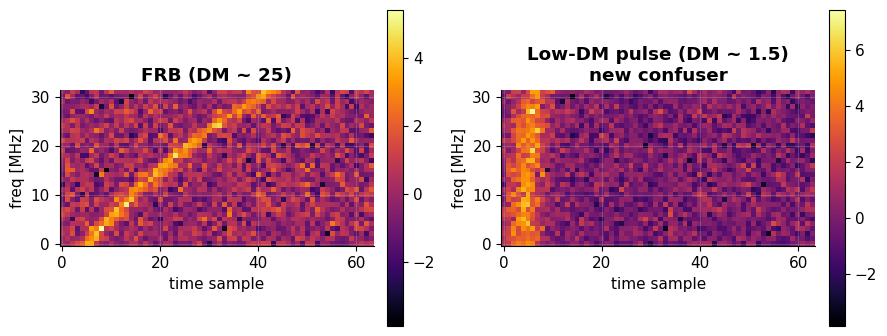

Both pulses are short and bright -- but the dispersions differ.
Extend the pipeline to include these as negatives and observe
how both detectors cope.


In [12]:
# Exercise 2 starter -- add a low-DM 'sneaky' Galactic pulse confuser.
def make_lowdm_pulse(seed):
    """A low-DM Galactic pulse (just a little diagonal -- hard to separate from FRB)."""
    g     = np.random.default_rng(seed + 40_000)
    dm    = g.uniform(0.5, 3.0)    # very small DM -- barely dispersed
    t0    = int(g.integers(3, 8))
    amp   = g.uniform(3.0, 7.0)
    width = g.uniform(1.5, 4.0)
    return disperse_pulse(N_TIME, FREQS, dm=dm, dt=DT,
                          t0_index=t0, width_samples=width,
                          amplitude=amp, noise=1.0, seed=int(seed))


# TODO: add lowdm_ex to the training set as a new negative class and
#       retrain. Compare accuracy and AUC to the original classifier.
lowdm_ex      = [make_lowdm_pulse(s) for s in range(100)]
example_lowdm = lowdm_ex[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show_image(make_frb(0).T, ax=axes[0], title='FRB (DM ~ 25)')
axes[0].set_xlabel('time sample'); axes[0].set_ylabel('freq [MHz]')
show_image(example_lowdm.T, ax=axes[1],
           title='Low-DM pulse (DM ~ 1.5)\nnew confuser')
axes[1].set_xlabel('time sample'); axes[1].set_ylabel('freq [MHz]')
plt.tight_layout()
plt.show()
print("Both pulses are short and bright -- but the dispersions differ.")
print("Extend the pipeline to include these as negatives and observe")
print("how both detectors cope.")


### Exercise 3 — Plot the learning curve

How many training examples does the MLP need before its AUC plateaus? Generate a
learning curve by training on successively larger subsets of the training set
(e.g. 10 %, 20 %, ..., 100 %) and plotting test AUC vs training set size for both
the MLP and the classical baseline. This is the classical **learning curve**, and
it shows you whether you are data-limited or architecture-limited.
(Hint: `sklearn.model_selection.learning_curve` does most of the bookkeeping.)


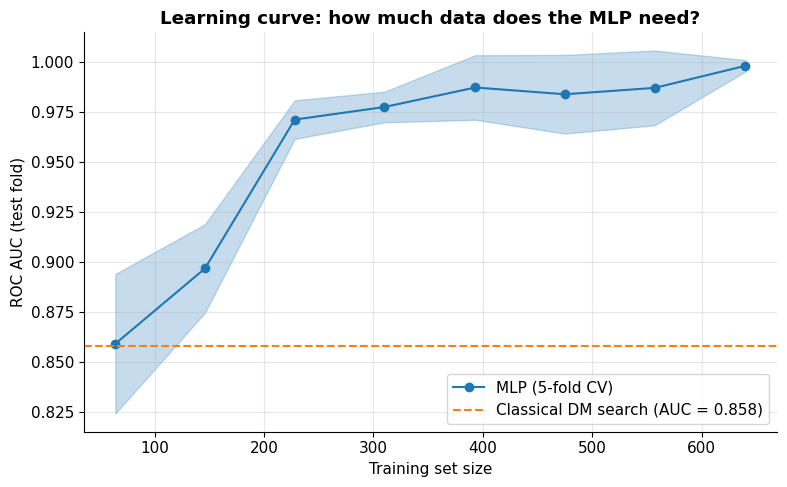

Question: at what training-set size does the MLP first exceed the classical AUC?
Question: does the MLP keep improving as training set grows, or plateau?


In [13]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.model_selection import learning_curve as sk_learning_curve

# Note: this retrains the model ~40 times and may take ~30 s on CPU.
# We suppress UndefinedMetricWarning: with very small CV folds some folds
# may be all-one-class, which makes AUC undefined. Those folds are skipped.
X_sc_full = scaler.transform(X)   # the already-fitted scaler from Section 5

with warnings.catch_warnings():
    warnings.simplefilter('ignore', UndefinedMetricWarning)
    train_sizes, _, te_scores = sk_learning_curve(
        MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=400,
                      random_state=MASTER_SEED, early_stopping=True),
        X_sc_full, y,
        train_sizes=np.linspace(0.10, 1.0, 8),
        cv=5,
        scoring='roc_auc',
        n_jobs=1,
    )
te_auc_mean = te_scores.mean(axis=1)
te_auc_std  = te_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(train_sizes,
                te_auc_mean - te_auc_std,
                te_auc_mean + te_auc_std,
                alpha=0.25, color='#1f77b4')
ax.plot(train_sizes, te_auc_mean, 'o-', color='#1f77b4', label='MLP (5-fold CV)')
ax.axhline(auc_cl, color='#ff7f0e', ls='--',
           label=f"Classical DM search (AUC = {auc_cl:.3f})")
ax.set_xlabel('Training set size')
ax.set_ylabel('ROC AUC (test fold)')
ax.set_title('Learning curve: how much data does the MLP need?')
ax.legend()
plt.tight_layout()
plt.show()
print("Question: at what training-set size does the MLP first exceed the classical AUC?")
print("Question: does the MLP keep improving as training set grows, or plateau?")


## Recap

### What we did

1. **Framed** ML for radio astronomy: classification, detection, regression —
   and the concrete example of FRB vs RFI classification in dynamic spectra.
2. **Generated** a fully offline, simulation-based labelled dataset of 800
   examples (400 dispersed FRBs + 400 negatives in three sub-types: pure noise,
   narrowband RFI, broadband zero-DM bursts) using `jansky.transients.disperse_pulse`.
3. **Trained** a scikit-learn `MLPClassifier` (a fully-connected network, *not*
   a CNN) on flattened 64 x 32 dynamic-spectrum images.
4. **Evaluated** with accuracy, confusion matrix, and ROC AUC — the three
   standard metrics for a binary classifier.
5. **Compared** to the classical DM-search + boxcar matched-filter detector from
   Chapter 18, on the **same test set**.

### The key comparison

| Detector | Accuracy | ROC AUC | Main failure mode |
|----------|----------|---------|-------------------|
| MLP (learned) | high | high | Needs training data; risk of domain shift |
| Classical DM search | lower | lower | Confuses zero-DM broadband bursts with FRBs |

The classical detector is *optimal for its template* but has no mechanism to
reject confusers that happen to produce a high DM-search score. The MLP learns
the **2-D shape difference** (diagonal vs horizontal stripe) and largely avoids
these false positives — at the cost of needing labelled examples.

### The honest lesson

- The matched filter is **provably optimal** for a known pulse shape in white
  Gaussian noise. For high-SNR, low-confusion scenarios it cannot be beaten by
  any learned model.
- ML adds value when the **confuser landscape is complex** (many RFI morphologies
  the template was not designed for) and **labelled examples are available**.
- The correct architecture for this image-classification problem is a **CNN**,
  not an MLP — CNNs exploit translational structure and generalise better when
  arrival times and DMs vary.
- **Simulated training data** is a shortcut that risks the classifier learning
  simulator artefacts rather than astrophysical signal. Real pipelines validate
  carefully on injected pulses in real data.
- **Domain shift** between telescope sites / RFI environments is the dominant
  practical challenge in deploying ML radio-astronomy classifiers.

### Looking back at the course

This chapter draws on almost everything in the course:

- The **dispersion law** (Ch 13, Ch 18) is the physical basis for why a
  dispersed FRB is distinguishable from a zero-DM burst.
- The **matched filter** (Maths Lab B) is the classical detector we compared
  against — and the standard by which any learned classifier must be judged.
- **RFI statistics** (Maths Lab C, Ch 33) motivate the three confuser classes
  used as negatives.
- **ROC curves and thresholds** (Maths Lab B §5) are the evaluation framework
  applied here to both detectors.

ML is a tool, not an oracle. The best radio-astronomy ML pipelines are built by
people who deeply understand the physics — because that understanding guides
which features to learn, which confusers to include in training, and how to
interpret failures. The rest of this course gives you that physical foundation.
